# Predicted Images
In this file we predict images using the different assessment methods.

## Code
### Imports

In [1]:
from pathlib import Path
import random
import yaml
import matplotlib.pyplot as plt
import numpy as np
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ToTensord
from monai.data import Dataset, DataLoader

from superresassess.experiments import ExperimentConfiguration
from superresassess.configurations_io import read_yaml_as_configuration
from superresassess.assessment.results import AssessResult

### Constants

In [2]:
SEED = 2024
RAN_EXPERIMENTS = Path("../graveyard/")
LOGS = Path("../logs")
MODEL_CONFIG = Path("../configurations/model.yaml")

# seed random for reproducibility of this script
random.seed(SEED)

### Getting three corresponding experiments

In [3]:
ran_experiments_paths = RAN_EXPERIMENTS.glob("*.yaml")

In [4]:

ran_experiments = [read_yaml_as_configuration(yaml_path=yaml_path, configuration=ExperimentConfiguration) for yaml_path in ran_experiments_paths]

In [5]:
# use pythons set function to get unique seeds, convert to list for use with random choice
unique_seeds = list(set([experiment.seed for experiment in ran_experiments]))

In [6]:
# use choice to get a random seed
random_seed = random.choice(unique_seeds)
print(random_seed)

2033


In [7]:
experiments_with_seed = [experiment for experiment in ran_experiments if experiment.seed == random_seed]

In [8]:
experiments_with_seed

[ExperimentConfiguration(assessment_method=<AssessmentEnum.nested_cross_validation: 'nested_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=2, num_workers=16, roi_size=(64, 64, 64), samples_per_image=200, limit_train_batches=1.0), validation_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), testing_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), n_internal_images=20, experiment_id='00030', seed=2033),
 ExperimentConfiguration(assessment_method=<AssessmentEnum.k_fold_cross_validation: 'k_fold_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size

### Get corresponding log files

In [9]:
experiments_with_best_model = []

for experiment in experiments_with_seed:
    assessment_result = read_yaml_as_configuration(LOGS.joinpath(str(experiment.experiment_id)).joinpath("assess_result.yaml"), AssessResult)
    experiments_with_best_model.append((experiment, assessment_result.best_model_path))

In [10]:
print(experiments_with_best_model)

[(ExperimentConfiguration(assessment_method=<AssessmentEnum.nested_cross_validation: 'nested_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=2, num_workers=16, roi_size=(64, 64, 64), samples_per_image=200, limit_train_batches=1.0), validation_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), testing_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), n_internal_images=20, experiment_id='00030', seed=2033), PosixPath('logs/00030/refit/refit.ckpt')), (ExperimentConfiguration(assessment_method=<AssessmentEnum.k_fold_cross_validation: 'k_fold_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(see

### Get external image to predict

In [11]:
experiment0 = experiments_with_seed[0]
external_images_yaml = LOGS.joinpath(str(experiment0.experiment_id)).joinpath("external_testing").joinpath("hparams.yaml")
with open(external_images_yaml, "r") as stream:
    # somehow these 
    external_images: str = yaml.safe_load(stream)['test_data']

In [12]:
# use random choice to randomly assing a subject
subject = random.choice(external_images)
print(subject)


{'img': PosixPath('data/HCP_1200/361941/processed/lr/T2w_acpc_dc_restore_brain.nii.gz'), 'lab': PosixPath('data/HCP_1200/361941/processed/hr/T2w_acpc_dc_restore_brain.nii.gz')}


In [13]:
# I made a mistake here, since I accidentaly saved this dict as str.
# There is no easy solution to convert this back, so I'll use 
# regular expressions
import re

# the group method returns a Match object or None, so this is a bit risky
subject_lr_path = Path("..").joinpath(re.search(r"(?<='img': PosixPath\(')(.*?)(?='\))", subject).group())


In [14]:
subject_hr_path = Path("..").joinpath(re.search(r"(?<='lab': PosixPath\(')(.*?)(?='\))", subject).group())

In [15]:
subject_data = [{"img": subject_lr_path, "lab": subject_hr_path}]

In [16]:
subject_data

[{'img': PosixPath('../data/HCP_1200/361941/processed/lr/T2w_acpc_dc_restore_brain.nii.gz'),
  'lab': PosixPath('../data/HCP_1200/361941/processed/hr/T2w_acpc_dc_restore_brain.nii.gz')}]

### Setup monai loader

In [17]:

monai_pipeline = Compose([
    LoadImaged(keys=["img", "lab"]),
    EnsureChannelFirstd(keys=["img", "lab"]),
    ToTensord(keys=["img", "lab"]),
])

In [18]:
test_ds = Dataset(data = subject_data, transform = monai_pipeline)

In [19]:
test_loader = DataLoader(test_ds, num_workers=1)

In [20]:
img = test_ds[0]["img"]
lab = test_ds[0]["lab"]


In [21]:
img.shape

torch.Size([1, 260, 311, 260])

### Make predictions with the models

In [22]:
experiments_with_best_model

[(ExperimentConfiguration(assessment_method=<AssessmentEnum.nested_cross_validation: 'nested_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=2, num_workers=16, roi_size=(64, 64, 64), samples_per_image=200, limit_train_batches=1.0), validation_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), testing_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), n_internal_images=20, experiment_id='00030', seed=2033),
  PosixPath('logs/00030/refit/refit.ckpt')),
 (ExperimentConfiguration(assessment_method=<AssessmentEnum.k_fold_cross_validation: 'k_fold_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(

In [23]:
threeway_holdout = experiments_with_best_model[1]
assert threeway_holdout[0].assessment_method == "k_fold_cross_validation"

In [24]:
from superresassess.model import LitReCNN
from superresassess.configurations_io import read_yaml_as_configuration
from superresassess.model import ReCNNConfiguration

model_config = read_yaml_as_configuration(MODEL_CONFIG, ReCNNConfiguration)
model = LitReCNN.load_from_checkpoint(Path("..").joinpath(threeway_holdout[1]), configuration=model_config)

In [25]:
result_k_fold_cross_validation = model.model.cuda()(img.cuda())

<Figure size 640x480 with 0 Axes>

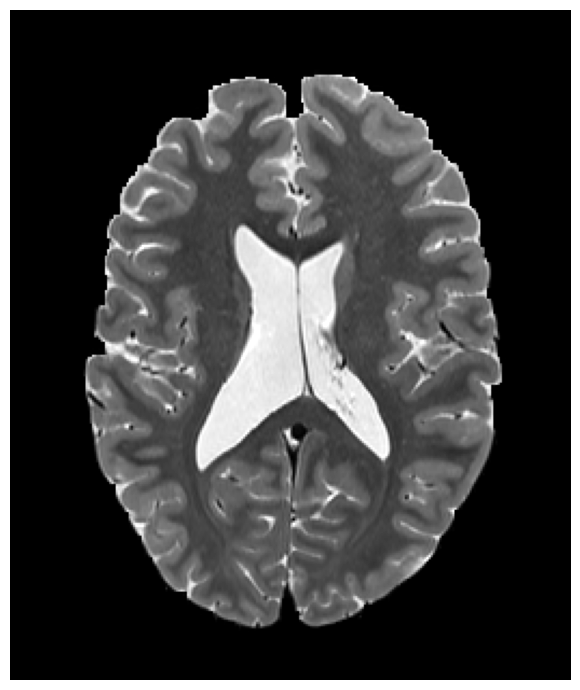

In [26]:

plt.figure()
fig = plt.figure(frameon=False)
fig.set_size_inches(6, 7)
ax = fig.add_subplot()
ax.set_axis_off()
fig.tight_layout()
ax.imshow(np.swapaxes(result_k_fold_cross_validation[0, :, :, 120].detach().cpu().numpy(), 0, 1)[::-1], cmap="gray", vmin=0, vmax=255)
fig.savefig("../figures/result_k_fold_cross_validation.png", dpi=300)